In [101]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [102]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [103]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [104]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [105]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps
        
        # 1. Create an empty list called legal_actions.
        legal_actions = []

        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        for action, move_coordinate in MOVES.items():
            row, col = state
            change_in_row, change_in_col = move_coordinate
            neighbour = (row + change_in_row, col + change_in_col)

            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)

        return legal_actions
        # raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        change_in_row, change_in_col = MOVES[action]
        return (row + change_in_row, col + change_in_col)
        # raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        
        # raise NotImplementedError("Complete GridProblem.action_cost")



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        state = node.state
        
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(state):
        #     s_prime <- problem.RESULT(s, action)
            state_prime = problem.result(state, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
            cost = node.path_cost + problem.action_cost(state, action, state_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(state=state_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [106]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [107]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        row, col = next_state
        
        # 2. Return self.terrain_costs[row][col].
        return self.terrain_costs[row][col]
        # raise NotImplementedError("Complete WeightedGridProblem.action_cost")

In [108]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [109]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    r1, c1 = state
    r2, c2 = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1 - r2) + abs(c1 - c2)
    # raise NotImplementedError("Complete manhattan_distance")


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    r1, c1 = state
    r2, c2 = goal
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)
    
    # raise NotImplementedError("Complete euclidean_distance")


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [110]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [111]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [112]:
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(state=problem.initial_state())
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node, problem), initial_node)
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        reached = {
          initial_node.state: initial_node}
        
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While the frontier is not empty:
        while frontier:
        # a. pop the node with the lowest f-value.
          node = frontier.pop()
        # b. if problem.is_goal(node.state): return a SearchResult with
        
          if problem.is_goal(node.state):
            # status "success" (use self.algorithm_name, nodes_expanded,
            # max_frontier_size, and len(reached)).
            return SearchResult(algorithm=self.algorithm_name, status="success", solution=node, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached))
  
        # c. increment nodes_expanded.
          nodes_expanded += 1
        # d. for each child in self.expand(problem, node):
          for child in self.expand(problem, node):
        #   i. s = child.state
            state = child.state
        #   ii. if s not in reached OR
        #   child.path_cost < reached[s].path_cost:
        #    reached[s] = child
            if state not in reached or child.path_cost < reached[state].path_cost:
              reached[state] = child
        #     push child with priority self.evaluation(child, problem)
              frontier.push(self.evaluation(child, problem), child)
              
        # e. update max_frontier_size with len(frontier).
          max_frontier_size = max(max_frontier_size, len(frontier))
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        return SearchResult(algorithm=self.algorithm_name, status="failure", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, reached_count=len(reached),)
        #raise NotImplementedError("Complete BestFirstSearch.search")

In [113]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)
              
        #raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")

In [114]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        
        return node.path_cost + self.h(node, problem)
        
        # raise NotImplementedError("Complete AStarSearch.evaluation")

In [115]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [116]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        
        return node.path_cost + self.weight * self.h(node, problem)
        
        # raise NotImplementedError("Complete WeightedAStarSearch.evaluation")

In [117]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [118]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18.0,52,5,56
1,A*,success,18,18.0,18,5,23
2,Weighted A* (W=2),success,18,18.0,18,5,23
3,Greedy,success,18,18.0,18,5,23


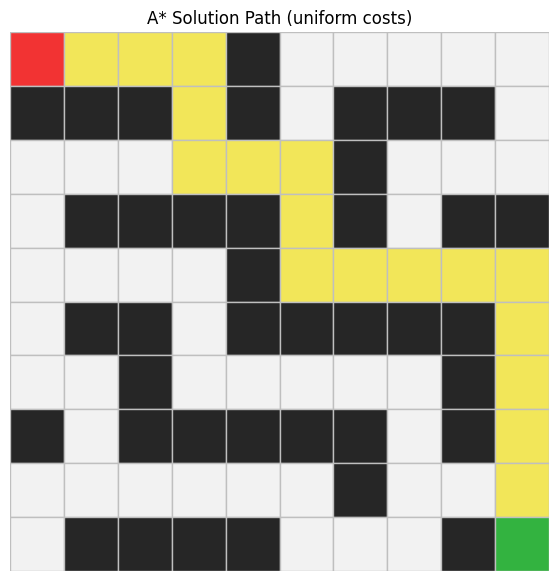

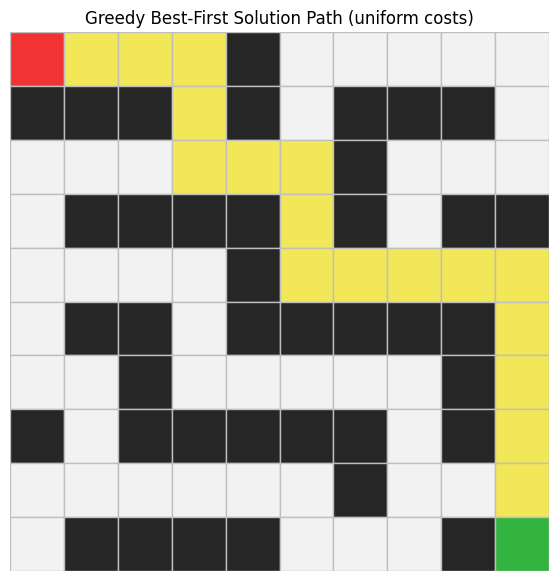

In [119]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [120]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


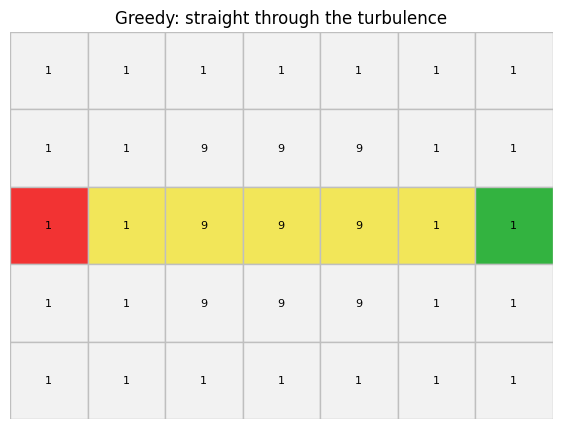

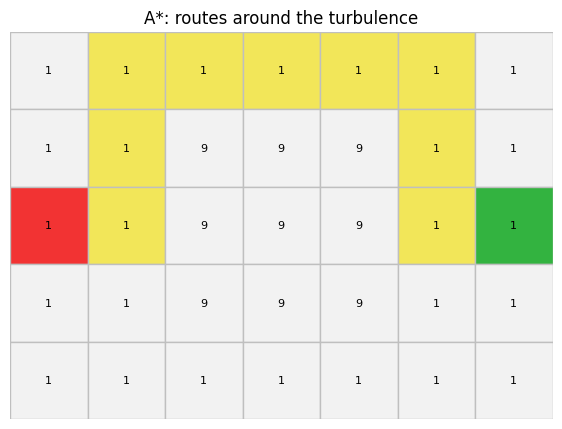

In [121]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [122]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    # 2. Return the inner function (do not call it).
    return h
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    # raise NotImplementedError("Complete inflated_heuristic")


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18.0,18,5,23
1,A* inflated x3 (uniform map),success,18,18.0,18,5,23
2,A* admissible (mild turbulence),success,10,10.0,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12.0,6,13,19


The inflated heuristic produced a suboptimal path only on the mild turbulence map, where the solution cost increased from 10 to 12 (2 additional cost units). However, it significantly reduced the search effort, expanding only 6 nodes compared to 29 for the admissible heuristic. This highlights the trade-off between optimality and efficiency: an inadmissible heuristic is faster but may not always return the least-cost path.

When speed is more important than perfect optimality, I would accept an inadmissible heuristic. For example, in real-time systems like drones or navigation in changing environments, getting a good path quickly is more valuable than waiting for the absolute best one.



In [123]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
        
        initial_node = Node(problem.initial_state())

        limit = self.heuristic(initial_node.state, problem.goal)
        
        
        
                
        
        raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
# ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

In [133]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
]

custom_costs_1 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1],
    [5, 5, 5, 1, 5, 1, 5, 5, 1, 5, 1, 5, 5, 5, 1],
    [1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1],
    [1, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 1, 5, 1],
    [1, 1, 1, 1, 1, 1, 1, 5, 1, 5, 1, 1, 1, 1, 1],
    [5, 5, 5, 5, 5, 5, 1, 5, 1, 5, 1, 5, 5, 5, 1],
    [1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 5, 1],
    [1, 5, 5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 1, 5, 1],
    [1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1],
    [5, 5, 1, 5, 5, 5, 1, 5, 1, 5, 1, 5, 5, 5, 1],
    [1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 5, 1],
    [1, 5, 5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 1, 5, 1],
    [1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 1, 5, 1],
    [5, 5, 1, 5, 5, 5, 1, 1, 1, 5, 5, 5, 1, 5, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1]
]

custom_start_1 = (0, 5)
custom_goal_1 = (14, 5)

# Example after completing:
custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,20,20,57,7,64
1,A*,success,20,20,29,6,35
2,Weighted A* (W=2),success,20,20,22,8,30
3,Greedy,success,20,20,21,8,29


This table compares UCS, A*, Weighted A* (W=2), and Greedy search on the same problem. All algorithms found the same solution with depth 20 and cost 20, meaning they all reached the optimal path.

From the table, we can see that UCS expands 57 nodes because it has no heuristic. A* expands 29 nodes while still guaranteeing an optimal solution. Weighted A* (W=2) expands 22 nodes by using a stronger heuristic, making the search more directed. Finally, Greedy Best-First Search expands 21 nodes because it focuses only on the heuristic.
Overall, increasing heuristic influence reduces search effort, but only A* guarantees optimality in all cases.

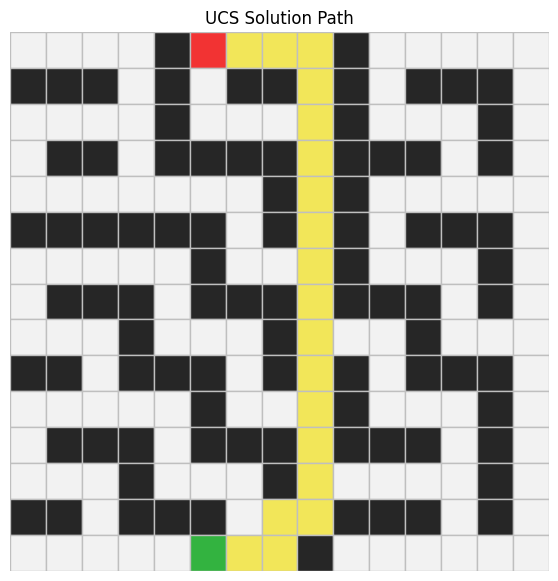

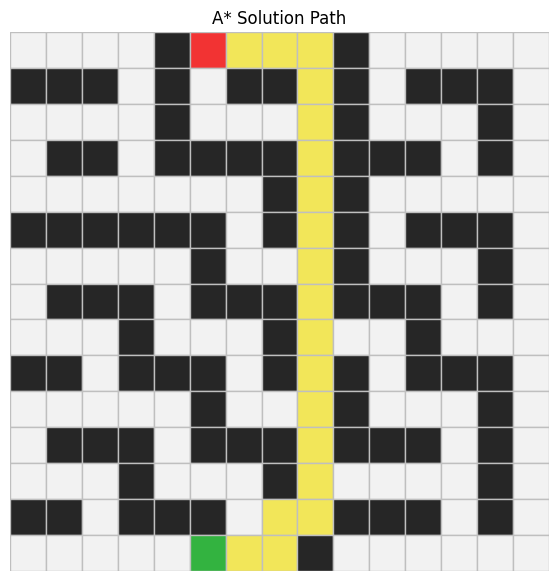

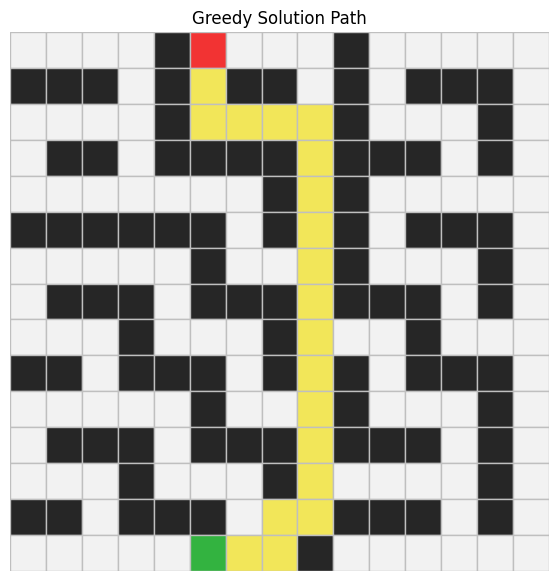

In [132]:
# Visualise solution paths.
# After your algorithms work, choose at least one algorithms and plot their paths.

ucs_result = custom_results_1[0]
astar_result = custom_results_1[1]
greedy_result = custom_results_1[3]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=ucs_result.path,
    title="UCS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=astar_result.path,
    title="A* Solution Path",
)


plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=greedy_result.path,
    title="Greedy Solution Path",
)



In [148]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1],
    [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1] 
]

custom_costs_2 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1],
    [1, 1, 5, 1, 5, 1, 5, 1, 5, 1, 5, 5, 5, 5, 1, 5, 1, 5, 5, 1],
    [5, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1],
    [1, 5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1, 5, 1],
    [1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1],
    [5, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 1],
    [1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1],
    [1, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 5, 5, 1],
    [1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 5, 1],
    [5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1, 5, 5, 5, 5, 5, 1, 5, 1],
    [1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1],
    [1, 5, 5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1],
    [1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1],
    [5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 5, 5, 1, 5, 5, 5, 1, 1, 5, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 1, 5, 5, 5, 5, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1],
    [5, 5, 5, 5, 5, 1, 5, 5, 1, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 5, 1, 1, 5, 1, 1, 1, 5, 1, 5, 1, 5, 5, 1, 1, 5],
    [1, 5, 5, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 1, 1, 1, 5, 1, 5]
]

custom_start_2 = (18, 0)
custom_goal_2 = (0, 19)

# Example after completing:
custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,55,55,158,6,163
1,A*,success,55,55,101,10,110
2,Weighted A* (W=2),success,55,55,80,13,91
3,Greedy,success,55,55,86,14,90


This table compares UCS, A*, Weighted A* (W=2), and Greedy search on the same problem. All algorithms found the same solution with depth 55 and cost 55, meaning they all reached the optimal path.

From the table, we can see that UCS expands 158 nodes because it has no heuristic. A* expands 101 nodes while still guaranteeing an optimal solution. Weighted A* (W=2) expands 80 nodes by using a stronger heuristic, making the search more directed. Finally, Greedy Best-First Search expands 86 nodes because it focuses only on the heuristic.

Overall, increasing heuristic influence reduces search effort, but only A* guarantees optimality in all cases.


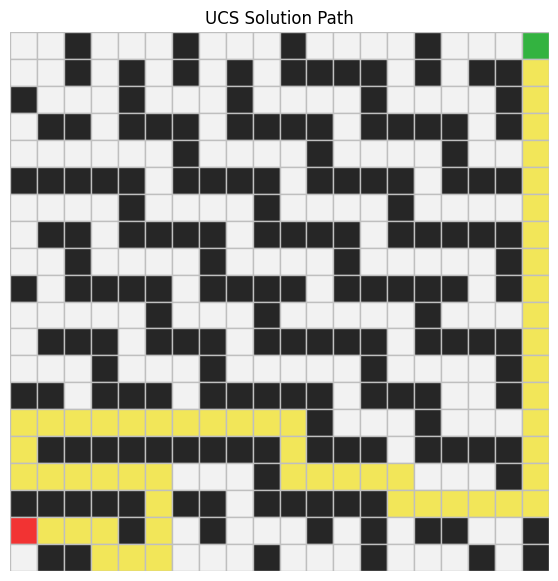

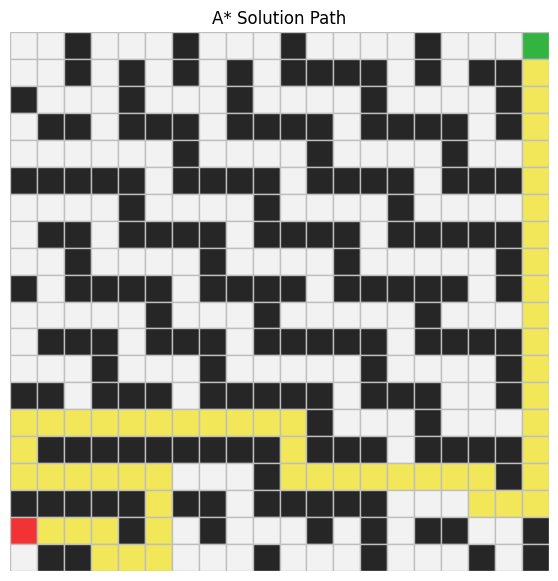

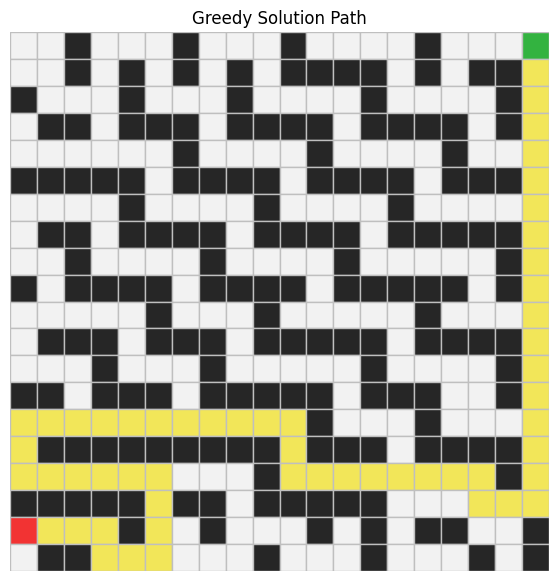

In [149]:
# Visualise solution paths.
# After your algorithms work, choose at least one algorithms and plot their paths.

ucs_result = custom_results_2[0]
astar_result = custom_results_2[1]
greedy_result = custom_results_2[3]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=ucs_result.path,
    title="UCS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=astar_result.path,
    title="A* Solution Path",
)


plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=greedy_result.path,
    title="Greedy Solution Path",
)



Q1.h(n) estimates the remaining cost or distance from the current node n to the goal. it helps the agent decide which node seems close to the goal.
The Knowledge coms from the coordinates of teh dron's current position and the goal position.

Q2.The relaxed problem rmoves restrictions that make movement difficult are
* Different terrain costs (all moves are treated equally)
*Obstacles or blocked cells.
*Any penalties associated with certain routes
In a relaxed such as this enviroment the drrone can simply move towards the main gaol without worying about any difficulty.

Q3. The Manhattan distance dominates Euclidean distance A* using a Manhattan distanc will usually expand fewer nodes than A* using the Euclidan distanceb

Q4.Manhattan distance assumes that each move costs at least 1,then the actual path cost can never be less than the Manhattan estimate. Therefore, Manhattan distance never overestimates the true cost and remains admissible.If a terrain cost of 0.5 is allowed, the actual path cost could become smaller than the Manhattan estimate.

Q1.The Greeedy ignors the path cost which is g(n) it only evaluates the node by the heuristic eestimate h(n) towards the goal. On the turrblence map, this punised Greedy because it could have choosen the path that closed closer to the goal but is expensive turbulence cell.

Q2.Expanding fewer nodes only means Greedy explored less of the search space.
It does not guarantee a better path or the lowest cost.
Greedy can be faster, but it often sacrifices optimality and can return a worse solution than A*.
A* is generally better when you need reliable optimal paths because it balances g(n) and h(n).

Q3. A good mission for Greedy is one where speed of finding a route is more important than finding the cheapest route


f(n) is the drone’s estimated total cost for the complete route through node n: g(n) is the cost already spent getting to n, and h(n) is the estimated cost remaining to reach the goal.

Q2.A* only knows it has found the best path to a state when that state is removed from the frontier with the lowest f(n).
If you test the goal too early, when the node is generated, you may accept a goal reached by a suboptimal route.
On the turbulence map, an early goal test could choose a goal node reached through expensive turbulent cells before A* has considered a cheaper path that arrives later with a better g(n).

Q3.In this lab, different paths to the same state can have different costs.
The dictionary stores the best node found so far for each state, so A* or UCS can replace a worse path if a lower-cost one appears.
A plain set only records that the state was seen, but does not keep the best path cost, so it cannot support cost-based path improvement.

Q4.If A* expands fewer nodes than UCS, the heuristic is helping focus search toward the goal.
The gap means the heuristic is informative: it reduces exploration by giving A* better guidance than blind cost-only search.
A larger gap indicates a stronger heuristic; a smaller gap means the heuristic is less helpful and A* behaves more like UCS.

Admissible means the heuristic never overestimates the true remaining cost to the goal.Consistent on the other hand means the heuristic obeys the triangle inequality for every action.
Consistent implies admissible.Admissible does not always imply consistent.

Q2.
The experiment showed that if the heuristic overestimates, A* can lose its optimality guarantee.
That means the lecture’s claim that A* returns an optimal path only holds when the heuristic is admissible.With an inadmissible heuristic, A* may choose a path that looks cheaper under f(n) but is actually more expensive than another route.

Q3.Yes, Manhattan distance is consistent on the unit-cost grid.

Q1.
As W increases above 1, the heuristic h(n) becomes more dominant.For very large W, the behavior approaches Greedy search, which mostly follows the heuristic and mostly ignores accumulated
cost.

Q2.Weighted A* guarantees that the returned path cost is at most W times optimal.

Q3.I would choose Weighted A* with a moderate weight, not pure A* and not pure Greedy.This reduces planning time compared to A* while still keeping the route close to optimal.

Q1.
A* stores two large structures,the frontier/open list with all generated fringe nodes,the reached/closed set with every visited state and its best path cost.That means A* keeps most of the search tree in memory until it finds the goal. AIDS avoids it by keeping the current path so the memory is prroportional to the search depth.

Q2.the terrain cost should include
*weather forecasts and changing wind conditions,
*dynamic no-fly zones or temporary airspace restrictions,
*battery state and remaining range,
*risk factors such as turbulence, congestion, or sensor/communication coverage,
*terrain elevation, obstacles, and terrain type that affect energy use.

Q3.If the drone is tracking a moving target the heuristic breaks becasue the heuristic aint stabl again, an already planned path can become invalid mid-way and optimally and feasibility guarantes can fail.